Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [ ]:
def get_dataset_indices(n_dataset, n_sample):
    
    print(f"Loaded {n_dataset} images")
    indices_dataset = np.random.permutation(n_dataset)
    dataset_sample = []
    for i in np.linspace(0, n_dataset, (n_sample+1), dtype = int):
        if i == 0:
            n_start = 0
        else:
            dataset_sample.append(indices_dataset[n_start:i])
            n_start = i 
    print(f"Data set divided in {n_sample} sets of {len(dataset_sample[0])} images")
    return dataset_sample

def check_create_folders(main_folder):
    if not(os.path.exists(os.path.join(args.root_focus, main_folder))):
        os.makedirs(os.path.join(args.root_focus, main_folder), exist_ok=True)
    for i_img, img_id in enumerate(Imagenet_urls_ILSVRC_2016):
        focus_dir = os.path.join(args.root_focus, main_folder, img_id)
        os.makedirs(focus_dir, exist_ok=True)

# From a model prediction :

In [ ]:
from torchvision.utils import save_image

num_notebook = 0 # change this to select another part of the dataset to run 

# The dataset to import images from
data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
#args.root_focus  = f'{DATAROOT}/{datetag}_Imagenet_focus' # Directory containing images


model_name = 'resnet101'
model_data_set_type = 'bbox'
args.do_saccade = True

for folder in ['val', 'train']:
    args.folders = [folder] # type of images to use
    folder = args.folders[0]
    for do_polar in [False, True]:
        args.do_polar = do_polar
        print(f'{args.do_polar=}')
        print(50*'.')
    
        if args.do_polar :
            args.root_focus += f'{DATAROOT}/Imagenet_focus_retino'
        else:
            args.root_focus  = f'{DATAROOT}/Imagenet_focus' # Directory containing image
    
        check_create_folders(folder)
    
        model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt'
        
        model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
            
        image_dataset = image_datasets_transforms(args, shuffle=False, verbose=False)
        
        annotations = get_annotation('csv')
    
        
        
        df_map = None
        n_dataset = len(image_dataset)
        dataset_sample = get_dataset_indices(n_dataset, 6)
        
        df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_focus_{folder}_{num_notebook}.parquet'
        print(df_filename)
        with torch.no_grad():
            for ind in tqdm(dataset_sample[num_notebook]):
                
                # initialising names
                fname = image_dataset.imgs[ind][0]
                fname_focus = fname.replace(os.path.join(args.root, folder), os.path.join(args.root_focus, folder))
                
                if not(os.path.exists(fname_focus)):
                    (image, label) = image_dataset[ind]
                    since = time.time()
                    image = image.to(device, non_blocking=True)
            
                    heat_map = torch.nn.functional.softmax(model(image), dim=1)
            
                    image_name = fname.split('/')[-1].split('.')[0]
                    heatmap_label = heat_map[:, label]
        
                    arg_max_prior = torch.argmax(heatmap_label)
                    position_prior = (arg_max_prior.item()%args.resolution[0], arg_max_prior.item()//args.resolution[1])
        
                    #save_image(image[arg_max_prior], fname_focus)  # uncomment to save the image
                    df_map_ = pd.DataFrame({'ImageId':fname, 'label':label, 'position_prior':[position_prior], 'time':time.time() - since})
                    df_map = store_pandas(df_map, df_map_)
            df_map.to_parquet(df_filename)

# From a saved file : 

args.do_polar=True
..................................................


  0%|                                                       | 3/50000 [00:00<1:09:44, 11.95it/s]

/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03160309/ILSVRC2012_val_00043498.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n04515003/ILSVRC2012_val_00018323.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n01698640/ILSVRC2012_val_00004402.JPEG


  0%|                                                       | 5/50000 [00:00<1:04:00, 13.02it/s]

/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n02788148/ILSVRC2012_val_00048426.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n02124075/ILSVRC2012_val_00023906.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03657121/ILSVRC2012_val_00029488.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n01855672/ILSVRC2012_val_00008834.JPEG


...

  0%|                                                      | 31/50000 [00:02<1:03:44, 13.07it/s]

/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n04040759/ILSVRC2012_val_00030739.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03124043/ILSVRC2012_val_00047590.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03388043/ILSVRC2012_val_00019659.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n02124075/ILSVRC2012_val_00023871.JPEG


  0%|                                                      | 36/50000 [00:02<1:00:23, 13.79it/s]

/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03444034/ILSVRC2012_val_00005110.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03584829/ILSVRC2012_val_00031726.JPEG
/mnt/d/Data/2024-05-24_Imagenet_focus_retino/val/n03793489/ILSVRC2012_val_00032891.JPEG


KeyboardInterrupt: 

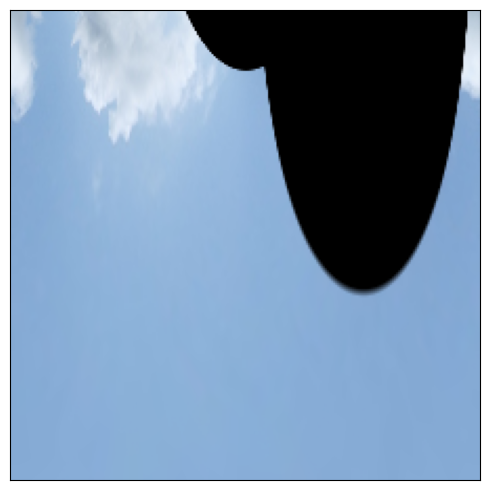

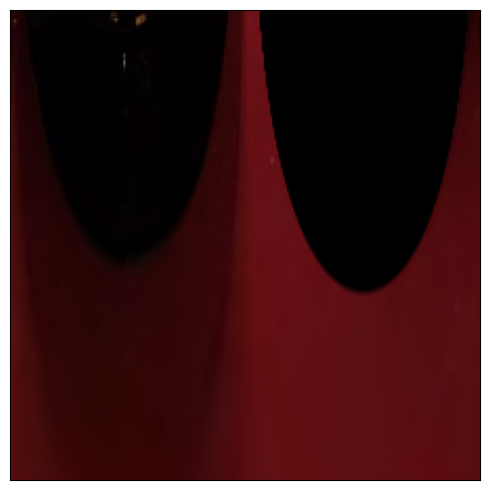

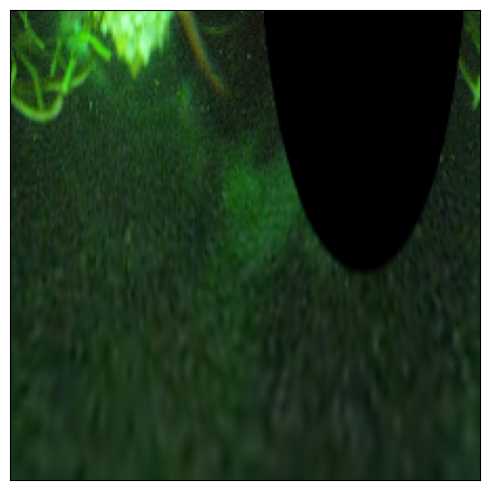

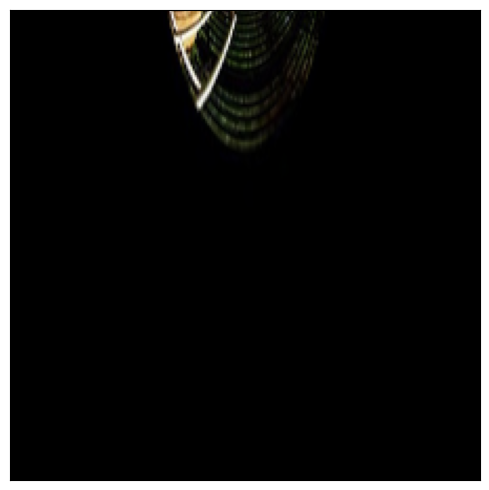

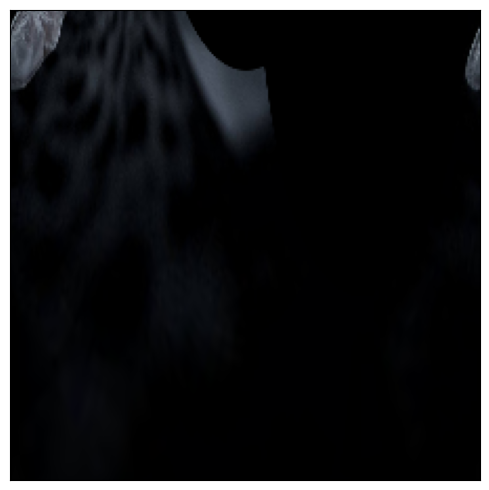

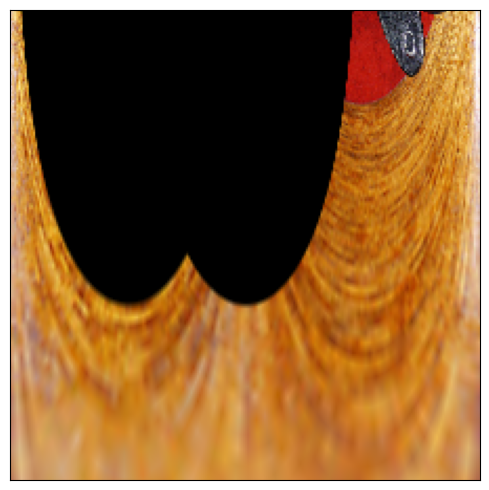

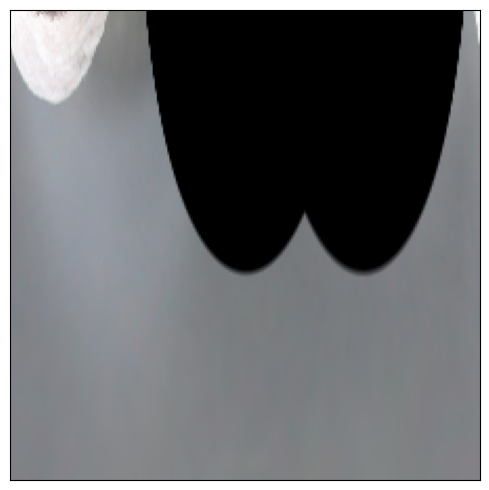

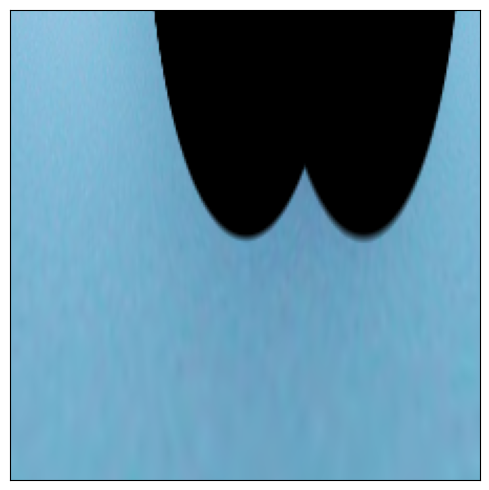

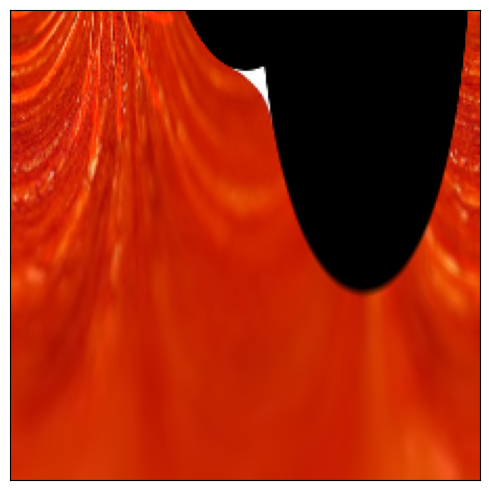

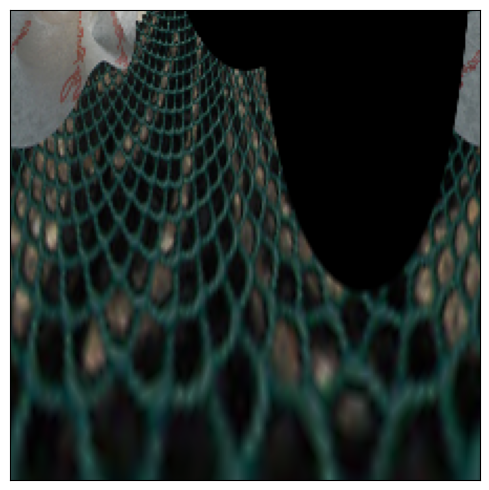

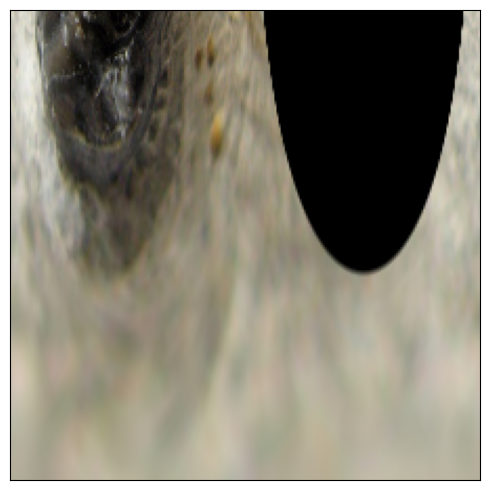

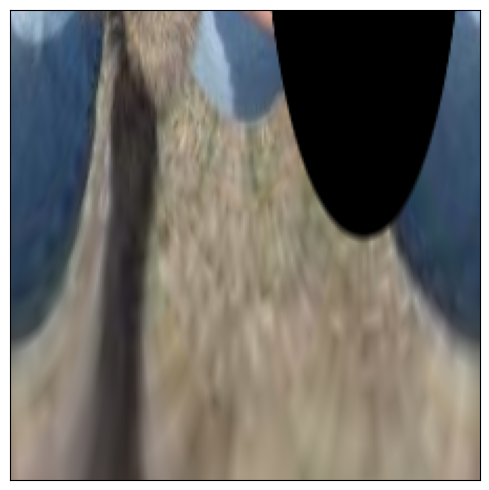

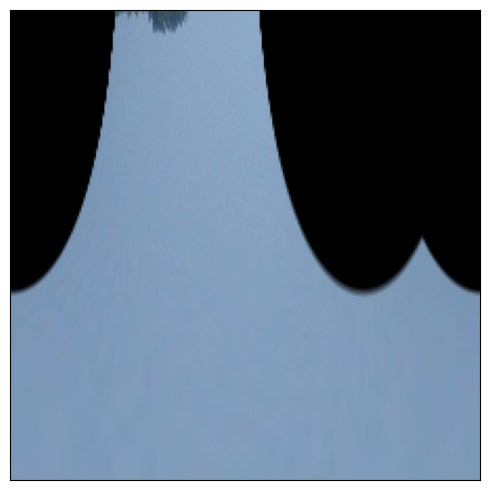

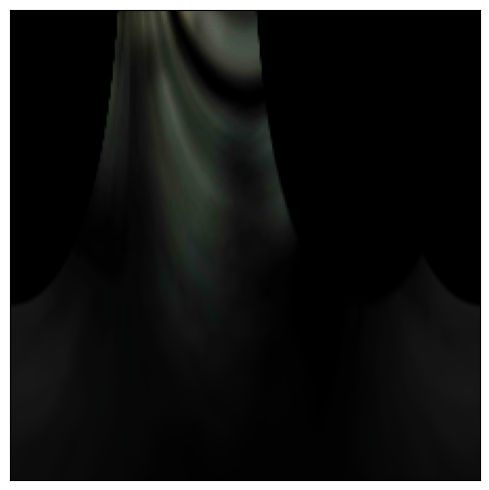

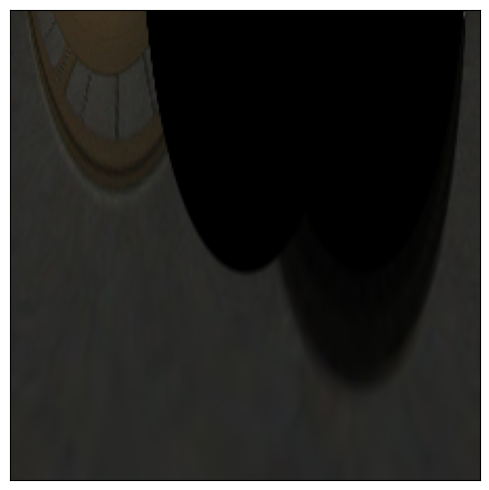

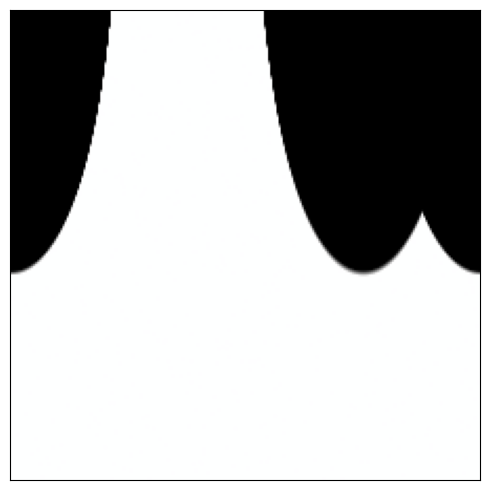

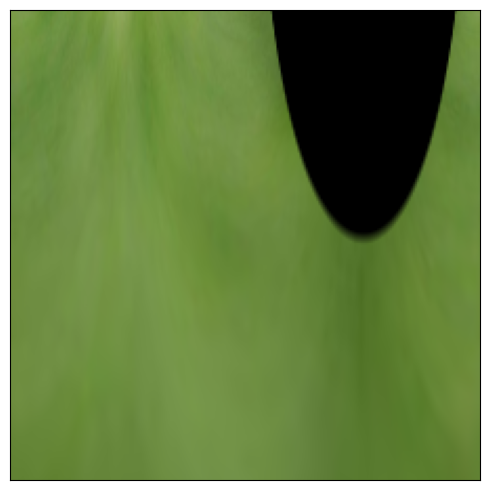

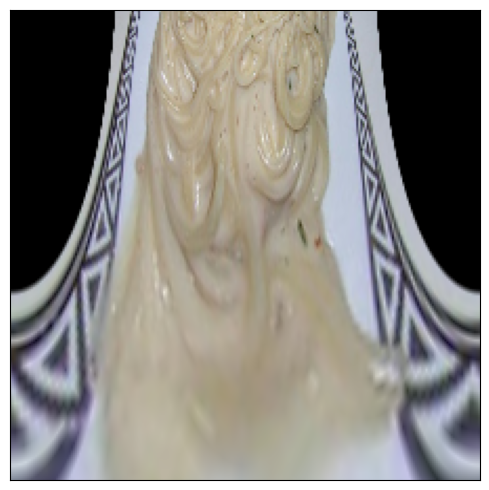

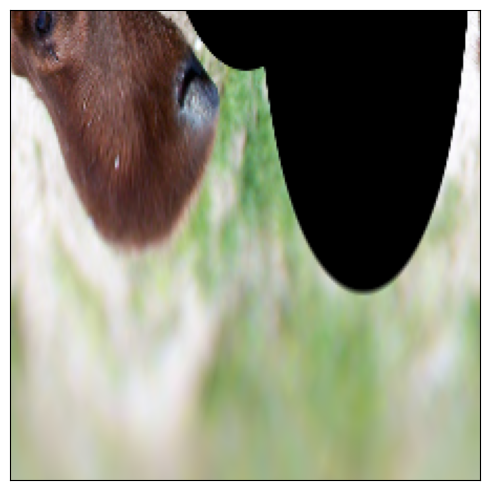

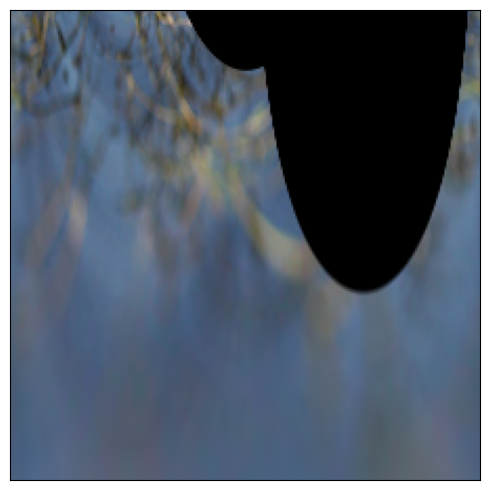

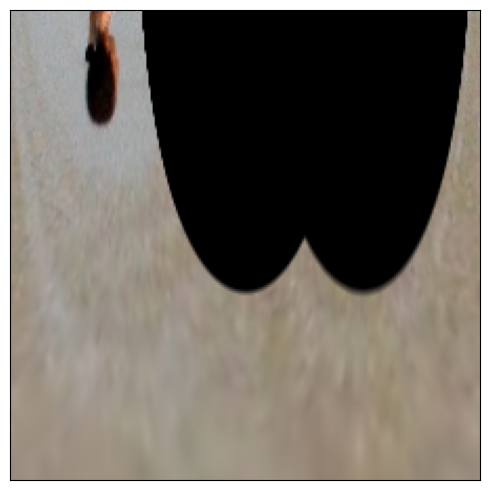

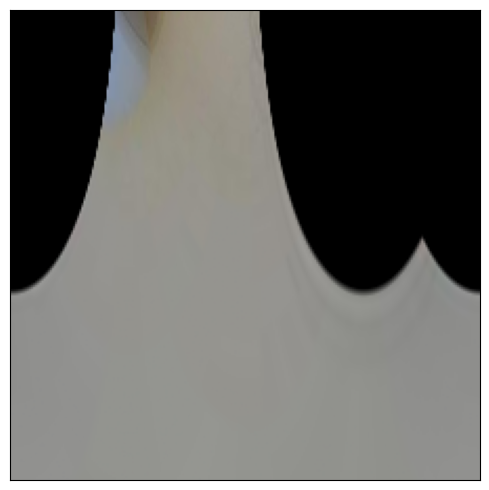

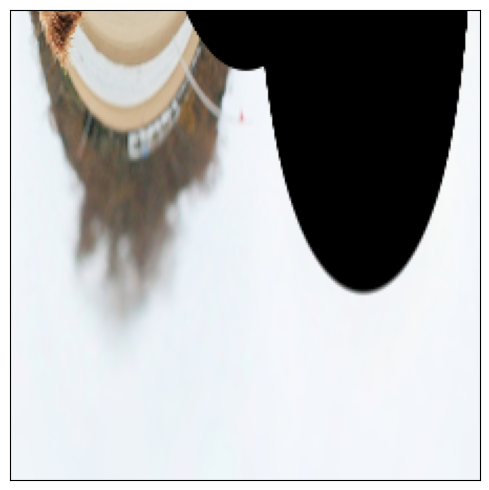

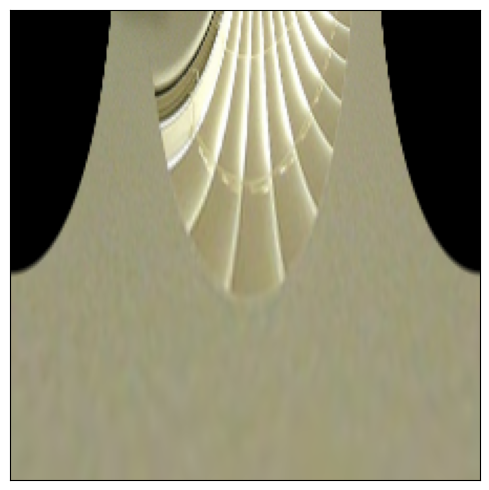

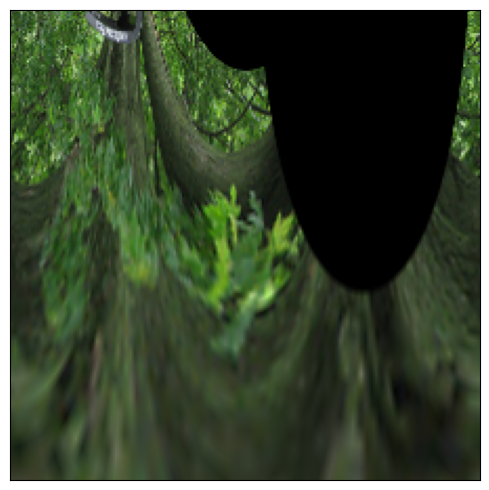

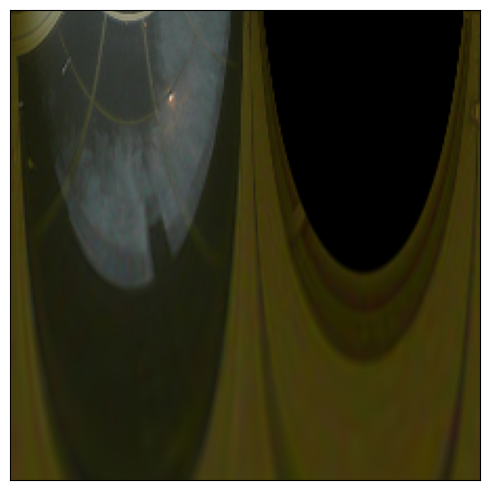

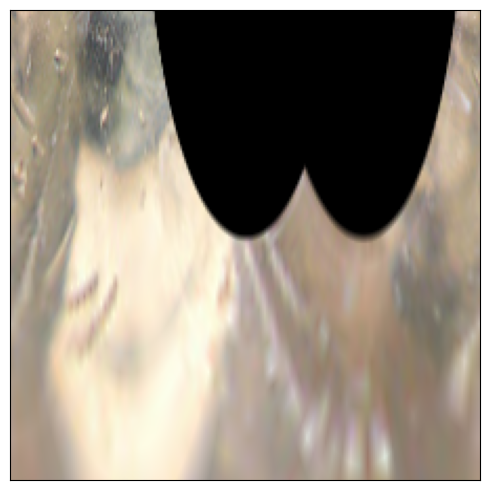

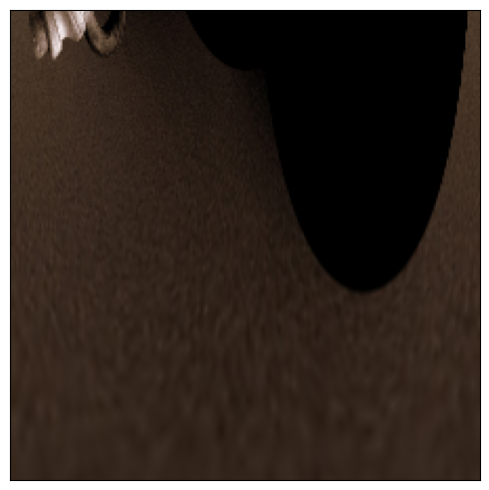

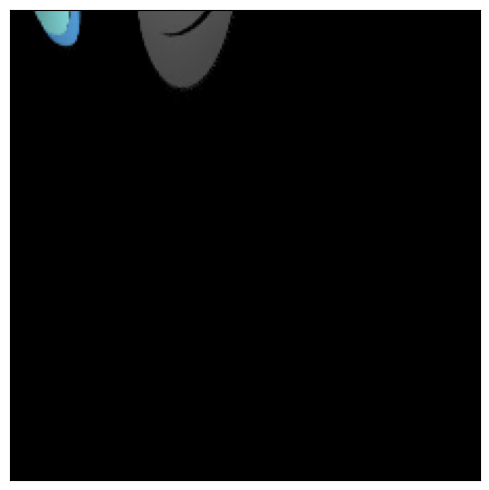

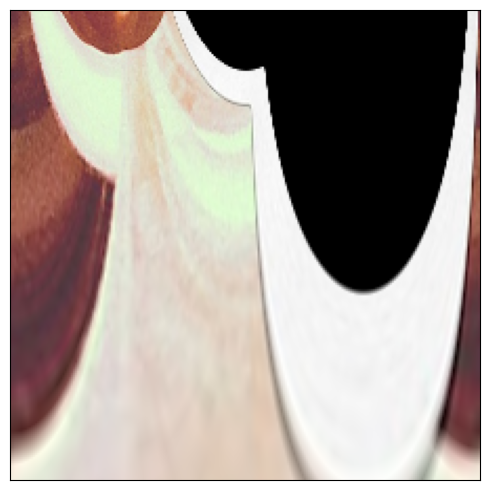

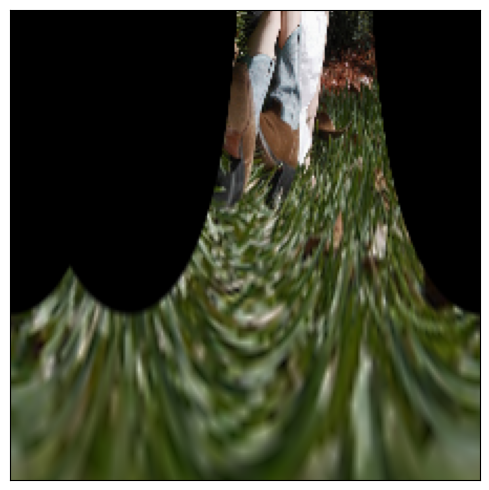

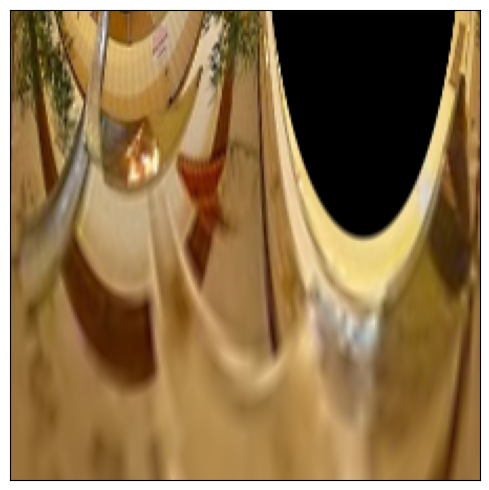

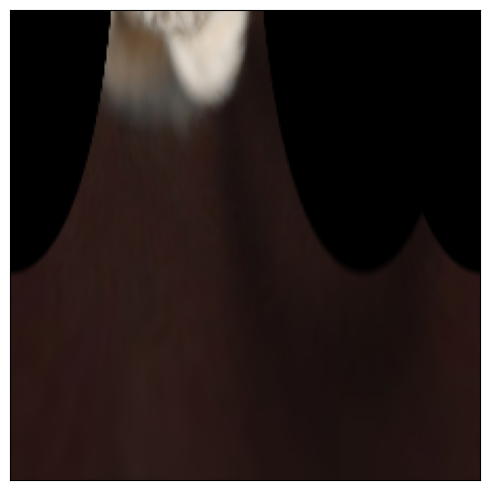

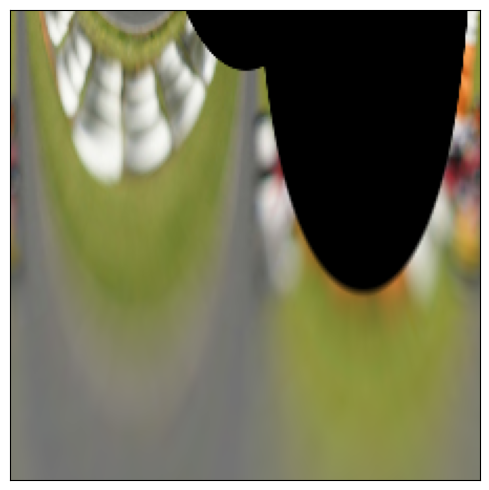

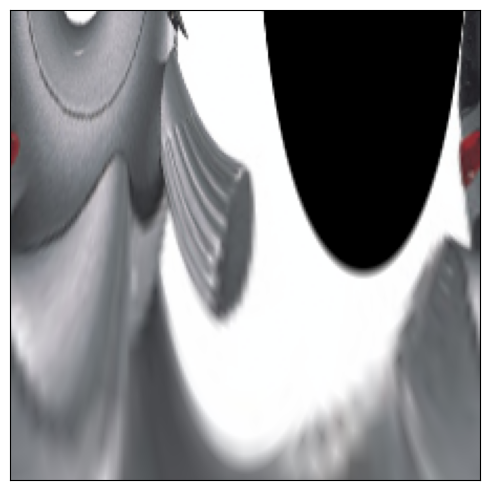

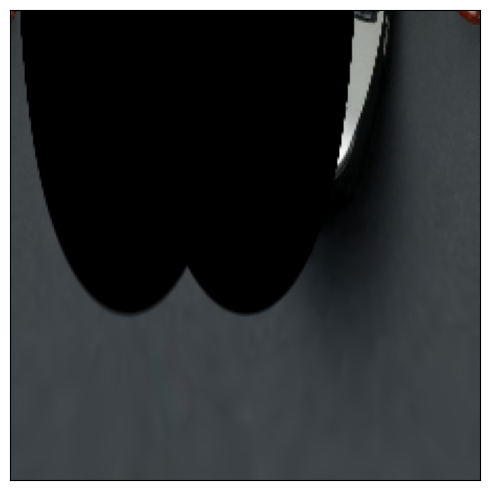

In [45]:
from torchvision.utils import save_image

# The dataset to import images from
data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.root_focus  = f'{DATAROOT}/Imagenet_focus' # Directory containing images


model_name = 'resnet101'
model_data_set_type = 'bbox'

args.do_saccade = True
args.folders = ['val'] # type of images to use
folder = args.folders[0]

for do_polar in [False, True]:
    args.do_polar = do_polar
    print(f'{args.do_polar=}')
    print(50*'.')
    
    if args.do_polar :
        args.root_focus += f'{DATAROOT}/Imagenet_focus_retino'
    else:
        args.root_focus  = f'{DATAROOT}/Imagenet_focus' # Directory containing images
        
    check_create_folders(folder)
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_test_map_border_full.parquet' #TODO_us
    
    df_map = pd.read_parquet(df_filename)
        
    image_dataset = image_datasets_transforms(args, shuffle=False, verbose=False)
    n_dataset = len(image_dataset)
    indices_dataset = np.random.permutation(n_dataset)
    for ind in tqdm(indices_dataset):
        
        # initialising names
        fname = image_dataset.imgs[ind][0]
        fname_focus = fname.replace(os.path.join(args.root, folder), os.path.join(args.root_focus, folder))
        if not(os.path.exists(fname_focus)):
    
            (image, label) = image_dataset[ind]
            pos = df_map[df_map['ImageId']==fname.split('/')[-1].split('.')[0]]['position_prior'].item()
            #imshow(image[pos[0]*pos[1]])
            #save_image(image[pos[0]*pos[1]], fname_focus)  # uncomment to save the image
